# Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

##### Resolución
Se decide usar algunos libros de Fyodor Dostoyevsky (en inglés) como corpus, descargados de [Project Gutenberg](https://www.gutenberg.org/).

Estos libros contienen un encabezado y un pie, con metadata, propios de Gutenberg, pero se indica claramente donde empieza el libro y donde termina, mediante el texto `*** START OF ... ***` y `*** END OF ... ***`, por lo cual se utiliza regex para encontrar estas cadenas y mantener únicamente lo que se encuentra entre ellas.

Luego, se unen todos en una misma variable de texto a la cual se aplicará el preprocesamiento.

In [1]:
import os
import urllib.request
import re

BOOKS_DIR = "books_dataset"
os.makedirs(BOOKS_DIR, exist_ok=True)

books = {
    "crime_and_punishment.txt": "https://www.gutenberg.org/files/2554/2554-0.txt",
    "the_brothers_karamazov.txt": "https://www.gutenberg.org/files/28054/28054-0.txt",
    "white_nights_and_other_stories.txt": "https://www.gutenberg.org/files/36034/36034-8.txt",
    "the_idiot.txt": "https://www.gutenberg.org/files/2638/2638-0.txt",
}

In [2]:
for filename, url in books.items():
    filepath = os.path.join(BOOKS_DIR, filename)
    if not os.path.exists(filepath):
        print(f"Descargando {filename}...")
        urllib.request.urlretrieve(url, filepath)
        print("Hecho")
    else:
        print(f"{filename} ya existe, se omite la descarga")

crime_and_punishment.txt ya existe, se omite la descarga
the_brothers_karamazov.txt ya existe, se omite la descarga
white_nights_and_other_stories.txt ya existe, se omite la descarga
the_idiot.txt ya existe, se omite la descarga


In [3]:
def extract_gutenberg_text(raw):
    match = re.search(r'\*\*\* START OF .+? \*\*\*(.+?)\*\*\* END OF .+? \*\*\*', raw, re.DOTALL)
    if match:
        return match.group(1).strip()
    else:
        print("No se encontraron las marcas de Gutenberg. Se retorna archivo completo")
        return raw

In [4]:
# Se compone un único texto con el contenido de todos los libros.
all_text = ""
for book in os.listdir(BOOKS_DIR):
    with open(os.path.join(BOOKS_DIR, book), "r", encoding="utf-8", errors="ignore") as f:
        raw = f.read()
        all_text += "\n"
        all_text += extract_gutenberg_text(raw)
        print(f"Agregando {book}... ({len(all_text)})")


Agregando crime_and_punishment.txt... (1135109)
Agregando the_brothers_karamazov.txt... (3070318)
Agregando the_idiot.txt... (4418014)
Agregando white_nights_and_other_stories.txt... (5068452)


In [6]:
# Se evita usar la función text_to_word_sequence ya que la documentación indica que se
# encuentra deprecada (Todo el módulo tf.keras.preprocessing está deprecado)
# Por esto se usa la librería nltk.

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Gabriel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
sentence_tokens = []
sentences = sent_tokenize(all_text)  # lista de oraciones (strings)

for s in sentences:
    sentence_tokens.append(word_tokenize(s.lower()))

# Usar este para eliminar signos de puntuación del vocabulario
# for s in sentences:
#     tokens = [w for w in word_tokenize(s.lower()) if w.isalpha()]
#     if tokens:  # descartar oraciones que queden vacías
#         sentence_tokens.append(tokens)

In [8]:
# A ver cómo quedan las oraciones y palabras
print(sentences[0])
print(sentences[:1])
print(sentence_tokens[0])


CRIME AND PUNISHMENT

By Fyodor Dostoevsky



Translated By Constance Garnett




TRANSLATOR’S PREFACE

A few words about Dostoevsky himself may help the English reader to
understand his work.
['\nCRIME AND PUNISHMENT\n\nBy Fyodor Dostoevsky\n\n\n\nTranslated By Constance Garnett\n\n\n\n\nTRANSLATOR’S PREFACE\n\nA few words about Dostoevsky himself may help the English reader to\nunderstand his work.']
['crime', 'and', 'punishment', 'by', 'fyodor', 'dostoevsky', 'translated', 'by', 'constance', 'garnett', 'translator', '’', 's', 'preface', 'a', 'few', 'words', 'about', 'dostoevsky', 'himself', 'may', 'help', 'the', 'english', 'reader', 'to', 'understand', 'his', 'work', '.']


`word_tokenize` separa los signos de puntuación (puntos, comas, comillas simples y dobles, etc) como tokens individuales, que en teoria no aportan nada al modelo más que agrandar el vocabulario con ruido, sin embargo dado que la naturaleza de este trabajo es aprender se mantienen para ver cómo afectan. Igualmente se deja comentado el código que se usaría en el caso de querer ignorarlos.

In [9]:
from gensim.models.callbacks import CallbackAny2Vec
from gensim.models import Word2Vec

In [10]:
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Para el entrenamiento se considera que el corpus es grande y el vocabulario
# relativamente extenso, esto lleva a los siguientes parámetros del modelo:

w2v_model = Word2Vec(
    vector_size=300,    # Permite relaciones más complejas, aunque requiere muchos datos y cómputo
    window=6,           # Se usa una ventana grande, ya que se considera que el significado puede cambiar bastante con el contexto
    min_count=5,        # Se reduce el ruido que pueda aparecer de Gutenberg y vocabulario poco frecuente
    sg=1,               # Skip-gram suele rendir mejor con vocabulario grande
    negative=20,        # Usualmente entre 5-20, a mayor valor generalmente mejora la calidad (y el costo)
    seed=42 ,           # Para reproducibilidad
    workers=1,          # Necesario para que sea completamente determinístico (reproducibilidad)
)

In [12]:
w2v_model.build_vocab(sentence_tokens)
print("Cantidad de filas en el corpus:", w2v_model.corpus_count)
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))


Cantidad de filas en el corpus: 51246
Cantidad de words distintas en el corpus: 7762


In [13]:
# Entrenar los embeddings
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[callback()]
)


Loss after epoch 0: 12382667.0
Loss after epoch 1: 10932749.0
Loss after epoch 2: 10840708.0
Loss after epoch 3: 11973684.0
Loss after epoch 4: 11904656.0
Loss after epoch 5: 9589288.0
Loss after epoch 6: 2135000.0
Loss after epoch 7: 2100560.0
Loss after epoch 8: 2047744.0
Loss after epoch 9: 2022632.0
Loss after epoch 10: 1964736.0
Loss after epoch 11: 1910944.0
Loss after epoch 12: 1866200.0
Loss after epoch 13: 1799736.0
Loss after epoch 14: 1746816.0
Loss after epoch 15: 1687176.0
Loss after epoch 16: 1631936.0
Loss after epoch 17: 1576184.0
Loss after epoch 18: 1527128.0
Loss after epoch 19: 1507040.0


(14693677, 22747480)

In [14]:
# Términos de interés
iterms = [
    "son",
    "siberia",
    "happiness",
    "duty",
    "prince",
    "flat",
    "god"
]

for t in iterms:
    nterm = 8
    print(f"=== {t} ======================")
    print("Más similares:")
    for sim in w2v_model.wv.most_similar(positive=t, topn=nterm):
        print(f" - {sim}")
    print("Menos similares:")
    for sim in w2v_model.wv.most_similar(negative=t, topn=nterm):
        print(f" - {sim}")

=== son ======================
Más similares:
 - ('sons', 0.4396161437034607)
 - ('ivanitch', 0.40721434354782104)
 - ('dearest', 0.39000803232192993)
 - ("'my", 0.38816210627555847)
 - ('p', 0.3880462646484375)
 - ('benefactor', 0.37800875306129456)
 - ('librarian', 0.3739606440067291)
 - ('clerical', 0.37350165843963623)
Menos similares:
 - ('like.', 0.06447204202413559)
 - ('dry', 0.04969489574432373)
 - ('expensive', 0.0400179922580719)
 - ('form', 0.038156524300575256)
 - ('apparent', 0.031542059034109116)
 - ('succeeded', 0.02654278092086315)
 - ('glance', 0.025808310136198997)
 - ('zverkov', 0.025615883991122246)
=== siberia ======================
Más similares:
 - ('convicted', 0.44532424211502075)
 - ('convicts', 0.4435909688472748)
 - ('mines', 0.43738695979118347)
 - ('cadet', 0.4281814992427826)
 - ('north', 0.4253080189228058)
 - ('america', 0.42193081974983215)
 - ('baths', 0.40812793374061584)
 - ('van', 0.4077213704586029)
Menos similares:
 - ('hearing', 0.1153363883495

Los términos de interés seleccionados son: _son_, _siberia_, _happiness_, _duty_, _prince_, _flat_ y _god_. Se buscaron para cada uno de ellos los 8 más similares y los 8 menos similares según el modelo entrenado.

Se observa una coherencia general entre los niveles de similitud de los términos relacionados, destacándose algunos como Siberia (en el contexto de Dostoyevsky) o God.

En varios otros existe algún término difícil de asociar o sin mucho sentido. He a continuación algunos casos (no se escriben todos, es un breve análisis conceptual):
- son -> ivanitch: Ivanitch es un nombre propio, que aparece en todos los relatos, pero prácticamente no relacionado con hijo o familiar.
- son -> p: Literalmente lo relaciona con la letra 'p', la cual aparece en el corpus principalmente en la abreviación de postdata (P.S.) en cartas.
- prince -> ,: El símbolo de la coma aparece como el término más similar para príncipe. También uno de los más similares es la doble comilla ("). Se podría reintentar eliminando signos de puntuación.
- duty -> _�: Aparece un caracter que no se decodificó correctamente en el libro "White nights, and other stories".

In [15]:
# Reducción de dimensionalidad
from sklearn.manifold import TSNE
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

def reduce_dimensions(model, num_dimensions = 2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels
    
vectors, labels = reduce_dimensions(w2v_model)

In [17]:
MAX_WORDS=2000
fig = px.scatter(x=vectors[:MAX_WORDS, 0], y=vectors[:MAX_WORDS, 1], text=labels[:MAX_WORDS])
# fig.show(renderer="colab") # esto para plotly en colab
fig.show()

Se elige un número bastante grande de MAX_WORDS como para poder destinguir claramente las agrupaciones en un primer vistazo, sin embargo el framework permite hacer zoom y desplazarse por el gráfico, tal que se encontraron algunos clusters como los siguientes (las imágenes se encuentran en la carpeta resolucion_2_imgs/):

-Términos que hacen referencia a una persona, tanto artículos como nombres propios.

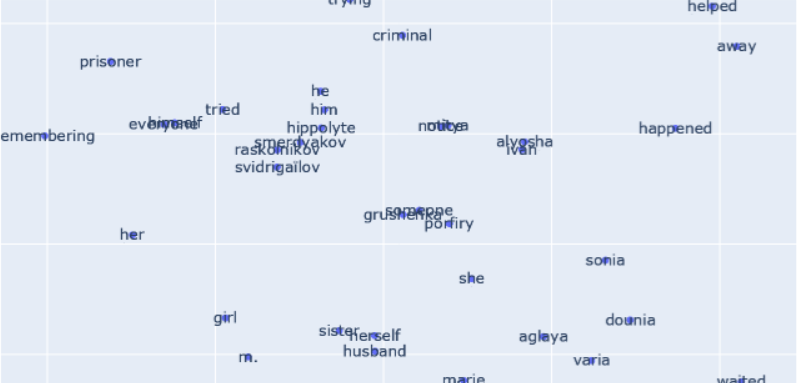

- Términos que pueden asociarse a una habitación de una casa o a muebles.

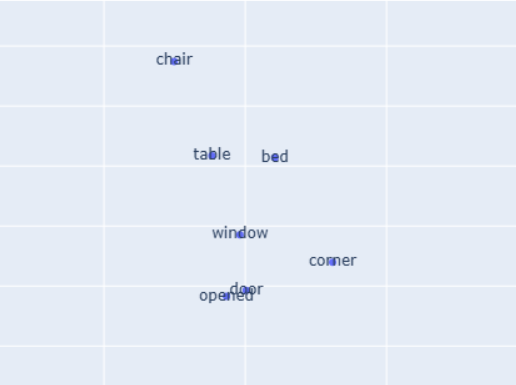

- Términos asociados a diálogos, es decir que se ubican antes o después de una línea de diálogo en la narración.

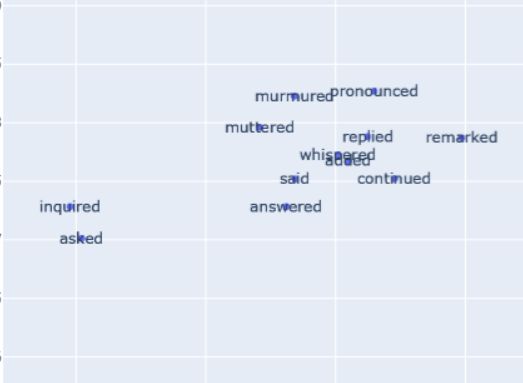

- Términos asociados a estilo y vestimenta, que pueden hacer referencia a descripciones de partes del cuerpo, ropa, etc.

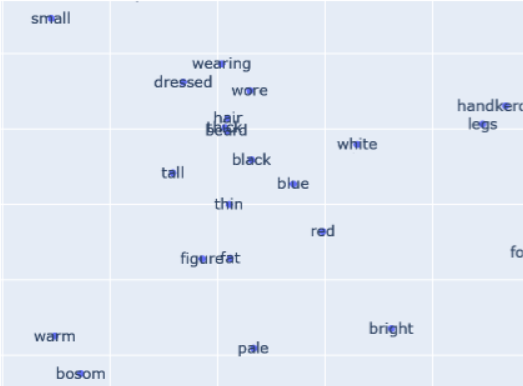